<a href="https://colab.research.google.com/github/NsElgezawy/AI-News-Intelligence-System-for-Classification-Fake-News-Detection-and-Summarization/blob/main/AI_News_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI News Intelligence System
### Complete NLP Pipeline :)
---

| Component | Paper | Year |
|-----------|-------|------|
| TF-IDF features | Sparck Jones, K. *A statistical interpretation of term specificity* | 1972 |
| Logistic Regression | Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR | 2011 |
| XGBoost | Chen & Guestrin. *XGBoost: A Scalable Tree Boosting System*. KDD | 2016 |
| Fake news detection | Ahmed et al. *Detection of Online Fake News Using N-Gram Analysis*. SCSS | 2017 |
| BERT | Devlin et al. *BERT: Pre-training of Deep Bidirectional Transformers*. NAACL | 2019 |
| BART summarization | Lewis et al. *BART: Denoising Seq2Seq Pre-training for NLG*. ACL | 2020 |
| KeyBERT | Grootendorst, M. *KeyBERT: Minimal keyword extraction with BERT*. Zenodo | 2020 |
| RAKE | Rose et al. *Automatic Keyword Extraction from Individual Documents* | 2010 |
| Class imbalance | Buda et al. *A systematic study of class imbalance in CNNs*. NN | 2018 |
| TextRank | Mihalcea & Tarau. *TextRank: Bringing Order into Texts*. EMNLP | 2004 |


## Setup

In [56]:
# Install all dependencies
!pip install -q scikit-learn xgboost nltk rake-nltk keybert sentence-transformers transformers torch joblib plotly streamlit
!pip install -q kaggle


In [57]:
import os, json, warnings, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')


## Data Loading & Organisation

> Load all three Kaggle datasets and structure clean DataFrames.

In [58]:
# ─── Colab: upload kaggle.json ───────────────────────────────────────────────
try:
    from google.colab import files
    files.upload()   # Upload kaggle.json
    os.makedirs('/root/.kaggle', exist_ok=True)
    !mv kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
except ImportError:
    pass  # Not running in Colab


Saving kaggle.json to kaggle.json


In [59]:
# ─── Download datasets ────────────────────────────────────────────────────────
!kaggle datasets download -d rmisra/news-category-dataset           --quiet
!kaggle datasets download -d hgultekin/bbcnewsarchive               --quiet
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset --quiet


Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
Dataset URL: https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0


In [60]:
# Unzip all
for f in os.listdir('.'):
    if f.endswith('.zip'):
        with zipfile.ZipFile(f) as z:
            z.extractall()
        print(f'Extracted: {f}')

Extracted: fake-and-real-news-dataset.zip
Extracted: bbcnewsarchive.zip
Extracted: news-category-dataset.zip


In [61]:
# ─── df_category (HuffPost) ───────────────────────────────────────────────────
df_news_raw = pd.read_json('News_Category_Dataset_v3.json', lines=True)
print('HuffPost shape:', df_news_raw.shape)
df_news_raw.head(3)


HuffPost shape: (209527, 6)


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23


In [62]:

# df_bbc (BBC)
# The Kaggle BBC file is tab-separated. Without sep="\t", pandas reads the
# whole row into one column and the dataset is unusable for EDA/modeling.
df_bbc_raw = pd.read_csv(
    'bbc-news-data.csv',
    sep='\t',
    encoding='latin-1',
    on_bad_lines='skip'
)
print('BBC shape:', df_bbc_raw.shape)
df_bbc_raw.head(3)


BBC shape: (2225, 4)


,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...


In [63]:
# ─── df_fake (Fake + Real merged) ────────────────────────────────────────────
df_fake_raw = pd.read_csv('Fake.csv')
df_real_raw = pd.read_csv('True.csv')
df_fake_raw['label'] = 0   # FAKE
df_real_raw['label'] = 1   # REAL
df_fake_combined = pd.concat([df_fake_raw, df_real_raw], ignore_index=True)
print('Fake+Real shape:', df_fake_combined.shape)
df_fake_combined.head(3)


Fake+Real shape: (44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0


## EDA  
**:)**

In [64]:
df_news_raw['category'].value_counts()

,count
category,
POLITICS,35602
WELLNESS,17945
ENTERTAINMENT,17362
TRAVEL,9900
STYLE & BEAUTY,9814
PARENTING,8791
HEALTHY LIVING,6694
QUEER VOICES,6347
FOOD & DRINK,6340


In [65]:
df_bbc_raw['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


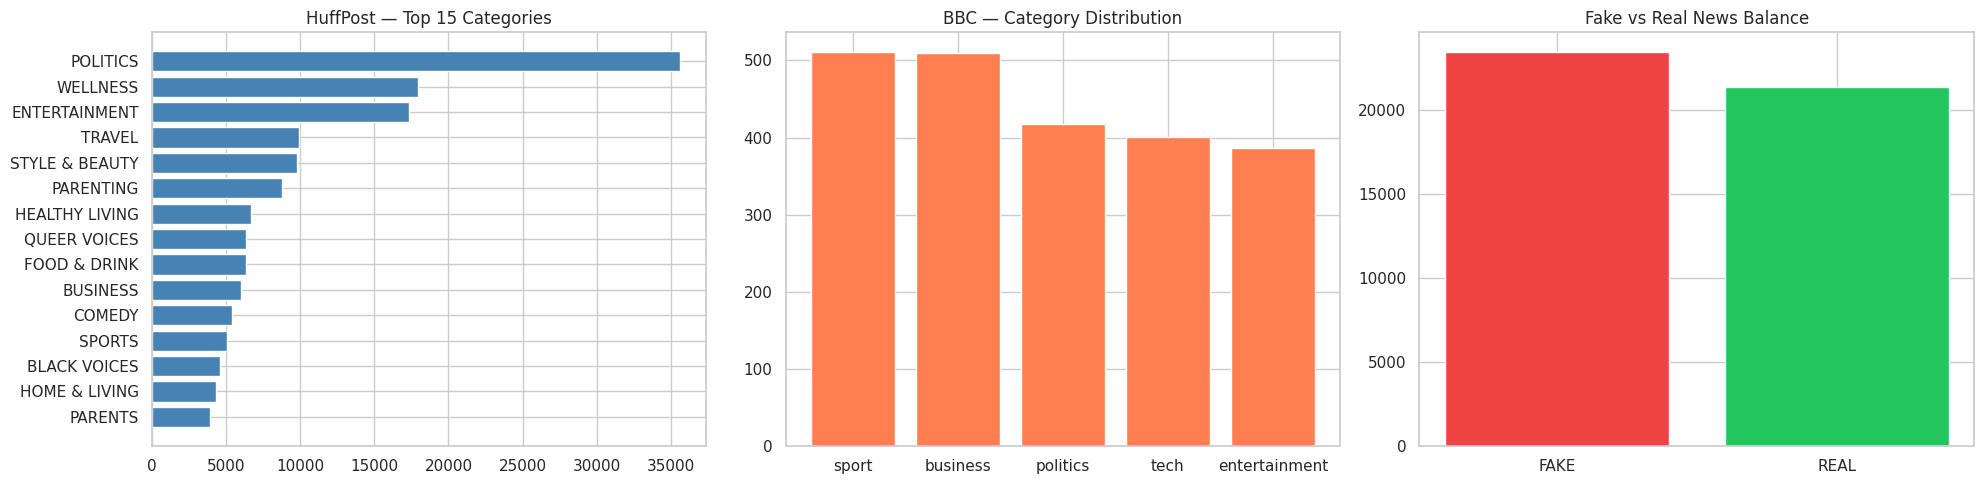

In [66]:
# ─── Category distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# HuffPost
cat_counts = df_news_raw['category'].value_counts().head(15)
axes[0].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[0].set_title('HuffPost — Top 15 Categories')
axes[0].invert_yaxis()

# BBC
try:
    bbc_cats = df_bbc_raw['category'].value_counts()
except:
    # BBC data might be tab-delimited in one column
    split = df_bbc_raw.iloc[:,0].str.split('\t', expand=True)
    bbc_cats = split[0].value_counts()
axes[1].bar(bbc_cats.index, bbc_cats.values, color='coral')
axes[1].set_title('BBC — Category Distribution')

# Fake vs Real
fake_counts = df_fake_combined['label'].value_counts()
axes[2].bar(['FAKE', 'REAL'], fake_counts.values, color=['#ef4444','#22c55e'])
axes[2].set_title('Fake vs Real News Balance')

plt.tight_layout()
plt.show()


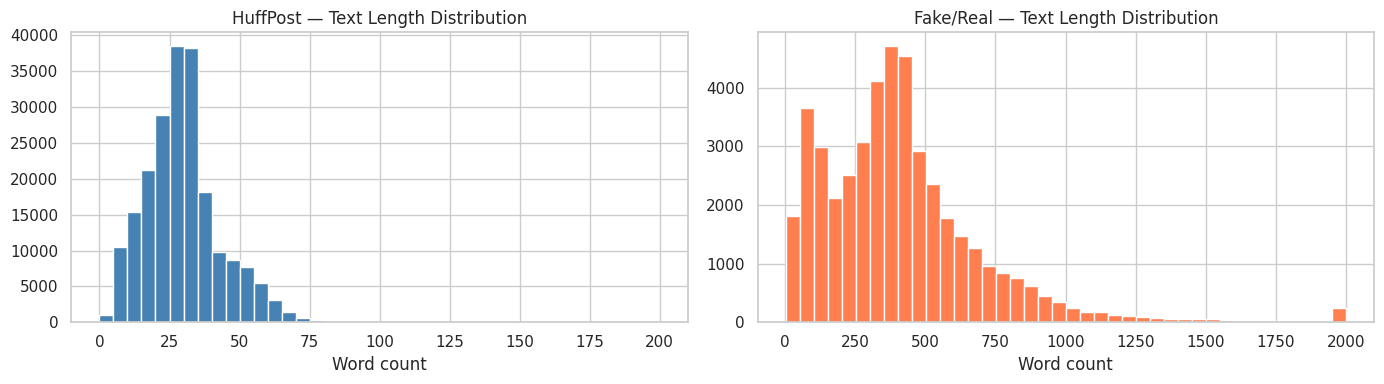

HuffPost  — avg words: 29.3
Fake/Real — avg words: 417.7


In [67]:
# ─── Text length distribution ─────────────────────────────────────────────────
df_news_raw['text_len'] = (df_news_raw['headline'].fillna('') + ' ' + df_news_raw['short_description'].fillna('')).str.split().str.len()
df_fake_combined['text_len'] = (df_fake_combined['title'].fillna('') + ' ' + df_fake_combined['text'].fillna('')).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_news_raw['text_len'].clip(0, 200), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('HuffPost — Text Length Distribution')
axes[0].set_xlabel('Word count')

axes[1].hist(df_fake_combined['text_len'].clip(0, 2000), bins=40, color='coral', edgecolor='white')
axes[1].set_title('Fake/Real — Text Length Distribution')
axes[1].set_xlabel('Word count')

plt.tight_layout()
plt.show()

print('HuffPost  — avg words:', df_news_raw['text_len'].mean().round(1))
print('Fake/Real — avg words:', df_fake_combined['text_len'].mean().round(1))


### Key Observations

- **HuffPost dataset**
  - Headlines + descriptions are short *(20–60 words)*
  - Suitable for fast **TF-IDF classification**

- **Fake vs Real dataset**
  - Articles are much longer *(500–1000 words)*
  - Provide richer signal for detection

- **Class balance**
  - Fake/Real dataset is **near-balanced**
  - No need for **SMOTE**

- **HuffPost categories**
  - Contains **42 categories**
  - Some are very rare *(< 0.5%)*
  - Should be merged into **OTHER**

In [68]:
# ─── Null & Duplicate check ───────────────────────────────────────────────────
print('=== HuffPost Nulls ===')
print(df_news_raw.isnull().sum())
print('\n=== Fake/Real Nulls ===')
print(df_fake_combined.isnull().sum())
print('\nHuffPost duplicates :', df_news_raw.duplicated().sum())
print('Fake/Real duplicates:', df_fake_combined.duplicated().sum())


=== HuffPost Nulls ===
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
text_len             0
dtype: int64

=== Fake/Real Nulls ===
title       0
text        0
subject     0
date        0
label       0
text_len    0
dtype: int64

HuffPost duplicates : 13
Fake/Real duplicates: 209


## Data Cleaning

In [69]:
# Category dataset
df_category = df_news_raw[['headline', 'short_description', 'category']].copy()
df_category['text'] = (
    df_category['headline'].fillna('') + '. ' +
    df_category['short_description'].fillna('')
)
df_category['label'] = df_category['category'].str.strip()
df_category = df_category[['text', 'label']].dropna()
df_category = df_category[df_category['text'].str.strip() != '']
df_category = df_category.drop_duplicates(subset='text')

In [70]:
# Normalize duplicate / near-duplicate HuffPost labels. This reduces label noise
# and directly addresses imbalance without inventing synthetic text.
CATEGORY_MAP_FINAL = {
    "POLITICS": "Politics",
    "U.S. NEWS": "Politics",
    "WORLD NEWS": "Politics",
    "WORLDPOST": "Politics",
    "THE WORLDPOST": "Politics",

    "TECH": "Technology",
    "SCIENCE": "Technology",

    "SPORTS": "Sports",

    "BUSINESS": "Business",
    "MONEY": "Business",

    "ENTERTAINMENT": "Entertainment",
    "COMEDY": "Entertainment",
    "WEIRD NEWS": "Entertainment",
    "MEDIA": "Entertainment",

    "HEALTHY LIVING": "Health",
    "WELLNESS": "Health",

    "STYLE & BEAUTY": "Lifestyle",
    "STYLE": "Lifestyle",
    "HOME & LIVING": "Lifestyle",
    "FOOD & DRINK": "Lifestyle",
    "TASTE": "Lifestyle",
    "TRAVEL": "Lifestyle",

    "PARENTING": "Family",
    "PARENTS": "Family",
    "WEDDINGS": "Family",
    "DIVORCE": "Family",

    "WOMEN": "Society",
    "BLACK VOICES": "Society",
    "QUEER VOICES": "Society",
    "LATINO VOICES": "Society",

    "ARTS": "Arts",
    "ARTS & CULTURE": "Arts",
    "CULTURE & ARTS": "Arts",

    "GREEN": "Environment",
    "ENVIRONMENT": "Environment",

    "CRIME": "Crime",

    "EDUCATION": "Education",
    "COLLEGE": "Education",

    "RELIGION": "Religion",

    "GOOD NEWS": "Misc",
    "IMPACT": "Misc",
    "FIFTY": "Misc"
}

df_category['label'] = df_category['label'].map(CATEGORY_MAP_FINAL).fillna("OTHER")

In [71]:
# Pool very small classes into OTHER. For a 42-class headline classifier,
# tiny classes hurt macro-F1 and produce unstable validation estimates.
# If you must keep every original category, lower this to 0.005 or 0.
other_ratio = (df_category['label'] == 'OTHER').mean()

# ── Debug prints ─────────────────────────────────────────────
print('df_category shape:', df_category.shape)
print('Number of labels:', df_category['label'].nunique())
print('OTHER ratio:', (df_category['label'] == 'OTHER').mean())
print(df_category['label'].value_counts().head(15))


df_category shape: (209038, 2)
Number of labels: 15
OTHER ratio: 0.0
label
Politics         46501
Lifestyle        34544
Entertainment    28465
Health           24628
Family           19736
Society          15537
Business          7743
Misc              6281
Sports            5077
Technology        4261
Environment       4060
Arts              3920
Crime             3558
Religion          2569
Education         2158
Name: count, dtype: int64


In [72]:
# Fake/Real dataset
df_fake = df_fake_combined[['title', 'text', 'label']].copy()
df_fake['text'] = df_fake['title'].fillna('') + '. ' + df_fake['text'].fillna('')
df_fake = df_fake[['text', 'label']].dropna()
df_fake = df_fake[df_fake['text'].str.strip() != '']
df_fake = df_fake.drop_duplicates(subset='text')

print('df_fake shape:', df_fake.shape)
print('Label dist:\n', df_fake['label'].value_counts())
print(df_category['label'].value_counts(normalize=True))

df_fake shape: (39105, 2)
Label dist:
 label
1    21197
0    17908
Name: count, dtype: int64
label
Politics         0.222452
Lifestyle        0.165252
Entertainment    0.136171
Health           0.117816
Family           0.094413
Society          0.074326
Business         0.037041
Misc             0.030047
Sports           0.024287
Technology       0.020384
Environment      0.019422
Arts             0.018753
Crime            0.017021
Religion         0.012290
Education        0.010323
Name: proportion, dtype: float64


## Text Preprocessing

In [73]:
import re, string
import nltk
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [74]:
for pkg in [
    'stopwords',
    'punkt',
    'wordnet',
    'omw-1.4',
    'punkt_tab',
    'averaged_perceptron_tagger_eng'
]:
    nltk.download(pkg, quiet=True)

In [75]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

In [76]:
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
PUNCT_TO_SPACE = str.maketrans({p: ' ' for p in string.punctuation})

In [77]:
def clean_text(text, lowercase=True, remove_punct=True, remove_sw=True, lemmatize=True):
    """NLP preprocessing used consistently by training and inference."""
    if not isinstance(text, str):
        return ''
    if lowercase:
        text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    if remove_punct:
        # Replace punctuation with spaces instead of deleting it. Deleting turns
        # "omicron-targeted" into "omicrontargeted" and "couldn't" into "couldnt".
        text = text.translate(PUNCT_TO_SPACE)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    if remove_sw:
        tokens = [t for t in tokens if t not in STOPWORDS]
    if lemmatize:
            pos_tags = pos_tag(tokens)
            tokens = [lemmatizer.lemmatize(t, get_wordnet_pos(p)) for t, p in pos_tags]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)

In [78]:
print('Preprocessing df_category...')
df_category['text_clean'] = df_category['text'].apply(clean_text)

Preprocessing df_category...


In [79]:
print('Preprocessing df_fake...')
df_fake['text_clean'] = df_fake['text'].apply(clean_text)

Preprocessing df_fake...


In [80]:
def show_sample(df, idx):
    if idx not in df.index:
        print(f" Index {idx} not found.")
        return

    original = df.loc[idx, 'text']
    cleaned = df.loc[idx, 'text_clean']

    print(f"🔹 Index: {idx}\n")

    print("📝 BEFORE (original):")
    print(original[:300])
    print("\n" + "-"*50 + "\n")

    print("✨ AFTER (cleaned):")
    print(cleaned[:300])

In [81]:
show_sample(df_category, 120)

🔹 Index: 120

📝 BEFORE (original):
NASA Aims For Saturday Launch Of New Moon Rocket After Fixing Fuel Leaks. The inaugural flight of the 322-foot Artemis I rocket — the most powerful ever built by NASA — was delayed late in the countdown Monday.

--------------------------------------------------

✨ AFTER (cleaned):
nasa aim saturday launch new moon rocket fix fuel leak inaugural flight 322 foot artemis rocket powerful ever build nasa delay late countdown monday


## Feature Engineering

In [82]:
!pip install gensim -q

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ─── Level 1: TF-IDF ──────────────────────────────────────────────────────────
# Config follows Joulin et al. (2017) 'Bag of Tricks' recommendations:
# sublinear_tf=True, bigrams (1,2), min_df=2
tfidf = TfidfVectorizer(
    max_features=40_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)
X_tfidf_cat = tfidf.fit_transform(df_category['text_clean'])
print('TF-IDF feature matrix shape (category):', X_tfidf_cat.shape)

TF-IDF feature matrix shape (category): (209038, 40000)


In [84]:
# ─── Level 2: Word2Vec features (mean embedding) ──────────────────────────────
# Uses Gensim to train a lightweight Word2Vec on our corpus
try:
    from gensim.models import Word2Vec
    sentences = [text.split() for text in df_category['text_clean'].dropna()]
    w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=5)
    print('Word2Vec vocab size:', len(w2v_model.wv))

    def mean_w2v(text):
        words = [w for w in text.split() if w in w2v_model.wv]
        return np.mean([w2v_model.wv[w] for w in words], axis=0) if words else np.zeros(100)

    # (Word2Vec embeddings are used as an optional alternative feature — TF-IDF is the primary)
    print('Word2Vec embeddings ready -.- (used as optional feature alternative)')
except ImportError:
    print('Gensim not available — Word2Vec skipped. TF-IDF is the primary feature.')


Word2Vec vocab size: 45931
Word2Vec embeddings ready -.- (used as optional feature alternative)


## prepare bbc news data for testing

In [85]:
df_category_test = df_bbc_raw[['title', 'content', 'category']].copy()

df_category_test.columns = ['headline', 'short_description', 'category']

In [86]:
df_category_test['text'] = (
    df_category_test['headline'].fillna('') + '. ' +
    df_category_test['short_description'].fillna('')
)
df_category_test['label'] = df_category_test['category'].str.strip()
df_category_test = df_category_test[['text', 'label']].dropna()
df_category_test = df_category_test[df_category_test['text'].str.strip() != '']
df_category_test = df_category_test.drop_duplicates(subset='text')

In [87]:
BBC_MAP = {
    "sport": "Sports",
    "business": "Business",
    "politics": "Politics",
    "tech": "Technology",
    "entertainment": "Entertainment"
}

df_category_test['label'] = df_category_test['label'].map(BBC_MAP)

In [88]:
other_ratio = (df_category_test['label'] == 'OTHER').mean()

# ── Debug prints ─────────────────────────────────────────────
print('df_category_test shape:', df_category_test.shape)
print('Number of labels:', df_category_test['label'].nunique())
print('OTHER ratio:', (df_category_test['label'] == 'OTHER').mean())
print(df_category_test['label'].value_counts().head(15))

df_category_test shape: (2127, 2)
Number of labels: 5
OTHER ratio: 0.0
label
Sports           505
Business         503
Politics         403
Entertainment    369
Technology       347
Name: count, dtype: int64


In [89]:
print('Preprocessing df_category_test...')
df_category_test['text_clean'] = df_category_test['text'].apply(clean_text)

Preprocessing df_category_test...


In [90]:
show_sample(df_category_test, 30)

🔹 Index: 30

📝 BEFORE (original):
Irish markets reach all-time high.  Irish shares have risen to a record high, with investors persuaded to buy into the market by low inflation and strong growth forecasts.  The ISEQ index of leading shares closed up 23 points to 6661.89 on Thursday, fuelled by strong growth in banking and financial 

--------------------------------------------------

✨ AFTER (cleaned):
irish market reach time high irish share rise record high investor persuade buy market low inflation strong growth forecast iseq index lead share close 23 point 6661 89 thursday fuel strong growth bank financial stock fall rate inflation january give fresh boost share advance month economy set stron


## Category Classification Model

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

In [101]:
# Encode labels after normalization/pooling.
le_cat = LabelEncoder()
df_category['label_enc'] = le_cat.fit_transform(df_category['label'])

df_category_test['label_enc'] = le_cat.transform(df_category_test['label'])

In [151]:
# [5000, 10000, 20000, 50000] test this numbers
CATEGORY_SAMPLE = 80000

if CATEGORY_SAMPLE:
    class_counts = df_category['label_enc'].value_counts()
    weights = 1 / class_counts
    sample_weights = df_category['label_enc'].map(weights)

    df_sample_cat = df_category.sample(
        n=CATEGORY_SAMPLE,
        weights=sample_weights,
        random_state=42
    ).reset_index(drop=True)

else:
    df_sample_cat = df_category.copy()

In [152]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    df_sample_cat['text_clean'],
    df_sample_cat['label_enc'],
    test_size=0.15,
    random_state=42,
    stratify=df_sample_cat['label_enc']
)

In [171]:
# Clipped class weights help minority classes without letting the rarest labels
# dominate the loss.
cat_classes = np.unique(y_train_cat)
raw_weights = compute_class_weight(class_weight='balanced', classes=cat_classes, y=y_train_cat)
MAX_CLASS_WEIGHT = 2.0
cat_class_weights = {
    int(cls): float(min(weight, MAX_CLASS_WEIGHT))
    for cls, weight in zip(cat_classes, raw_weights)
}

In [172]:
print(f'Train: {len(X_train_cat)}  Test: {len(X_test_cat)}')
print(f'Category labels used: {len(le_cat.classes_)}')
print(f'Class-weight range: {min(cat_class_weights.values()):.2f} to {max(cat_class_weights.values()):.2f}')

Train: 68000  Test: 12000
Category labels used: 15
Class-weight range: 0.63 to 2.00


In [173]:

# Model A: Logistic Regression baseline/production candidate
# Linear models on TF-IDF n-grams are usually strong for short news text.

lr_cat_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=100_000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=2,
        max_df=0.9,
        strip_accents='unicode'
    )),
    ('clf', LogisticRegression(
        max_iter=2000,
        C=2.0,
        class_weight=cat_class_weights,
        solver='saga',
        n_jobs=-1
    )),
])

print('Training Logistic Regression...')
lr_cat_pipe.fit(X_train_cat, y_train_cat)
lr_cat_preds = lr_cat_pipe.predict(X_test_cat)

lr_scores = {
    'accuracy': accuracy_score(y_test_cat, lr_cat_preds),
    'macro_f1': f1_score(y_test_cat, lr_cat_preds, average='macro', zero_division=0),
    'weighted_f1': f1_score(y_test_cat, lr_cat_preds, average='weighted', zero_division=0),
}
lr_f1 = lr_scores['macro_f1']
print(
    f"LogReg -> Acc={lr_scores['accuracy']:.4f} | "
    f"Macro-F1={lr_scores['macro_f1']:.4f} | "
    f"Weighted-F1={lr_scores['weighted_f1']:.4f}"
)


Training Logistic Regression...
LogReg -> Acc=0.6524 | Macro-F1=0.6450 | Weighted-F1=0.6509


In [174]:
import joblib, os
os.makedirs('models', exist_ok=True)
best_cat_name = 'Logistic Regression'
best_cat_pipe = lr_cat_pipe
best_cat_preds = lr_cat_preds
best_cat_scores = lr_scores

joblib.dump(best_cat_pipe, 'models/category_model.pkl')
joblib.dump(le_cat, 'models/category_label_encoder.pkl')
print(f'Category model saved: {best_cat_name} (Macro-F1={best_cat_scores["macro_f1"]:.4f})')

Category model saved: Logistic Regression (Macro-F1=0.6450)


In [175]:

# Evaluation report
report_labels = np.unique(np.concatenate([np.asarray(y_test_cat), np.asarray(best_cat_preds)]))
report_names = le_cat.inverse_transform(report_labels.astype(int))
print(f'Selected category model: {best_cat_name}')
print(
    classification_report(
        y_test_cat,
        best_cat_preds,
        labels=report_labels,
        target_names=report_names,
        zero_division=0
    )
)


Selected category model: Logistic Regression
               precision    recall  f1-score   support

         Arts       0.59      0.63      0.61       531
     Business       0.63      0.65      0.64       809
        Crime       0.63      0.77      0.69       493
    Education       0.59      0.69      0.64       320
Entertainment       0.64      0.59      0.61      1184
  Environment       0.59      0.66      0.62       552
       Family       0.74      0.74      0.74      1115
       Health       0.65      0.71      0.68      1167
    Lifestyle       0.73      0.75      0.74      1209
         Misc       0.42      0.38      0.40       724
     Politics       0.72      0.65      0.68      1267
     Religion       0.68      0.69      0.68       377
      Society       0.65      0.52      0.58      1046
       Sports       0.77      0.78      0.77       641
   Technology       0.57      0.61      0.59       565

     accuracy                           0.65     12000
    macro avg     

In [176]:
# Predict
bbc_preds = best_cat_pipe.predict(df_category_test['text_clean'])

# ─── Metrics ─────────────────────────────────────────────
bbc_acc = accuracy_score(df_category_test['label_enc'], bbc_preds)
bbc_f1 = f1_score(df_category_test['label_enc'], bbc_preds, average='macro')

print(f"BBC Accuracy: {bbc_acc:.4f}")
print(f"BBC Macro-F1: {bbc_f1:.4f}")

# ─── FIX: Use ONLY labels present in BBC ─────────────────
bbc_labels = np.unique(df_category_test['label_enc'])
bbc_names = le_cat.inverse_transform(bbc_labels.astype(int))

print("\n📊 BBC Classification Report:\n")

print(
    classification_report(
        df_category_test['label_enc'],
        bbc_preds,
        labels=bbc_labels,
        target_names=bbc_names,
        zero_division=0
    )
)

BBC Accuracy: 0.7428
BBC Macro-F1: 0.2608

📊 BBC Classification Report:

               precision    recall  f1-score   support

     Business       0.70      0.91      0.79       503
Entertainment       0.99      0.45      0.62       369
     Politics       0.92      0.67      0.78       403
       Sports       0.98      0.91      0.95       505
   Technology       0.99      0.65      0.78       347

    micro avg       0.87      0.74      0.80      2127
    macro avg       0.92      0.72      0.78      2127
 weighted avg       0.91      0.74      0.79      2127



here Macro-F1 = .2423 that is very low And the reason is Macro-F1 take avarage of F1 of all the classes (15) and bbc news have only 5 classes

In [177]:
bbc_labels = np.unique(df_category_test['label_enc'])

bbc_acc = accuracy_score(df_category_test['label_enc'], bbc_preds)

bbc_f1 = f1_score(
    df_category_test['label_enc'],
    bbc_preds,
    labels=bbc_labels,
    average='macro',
    zero_division=0
)

bbc_f1_weighted = f1_score(
    df_category_test['label_enc'],
    bbc_preds,
    labels=bbc_labels,
    average='weighted',
    zero_division=0
)

print(f"BBC Accuracy: {bbc_acc:.4f}")
print(f"BBC Macro-F1 (filtered): {bbc_f1:.4f}")
print(f"BBC Weighted-F1: {bbc_f1_weighted:.4f}")

BBC Accuracy: 0.7428
BBC Macro-F1 (filtered): 0.7825
BBC Weighted-F1: 0.7935
